# Python и введение в PyTorch. Полносвязная нейронная сеть

In [457]:
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import optuna
from sklearn.model_selection import train_test_split
from torch.utils.data import TensorDataset, DataLoader, WeightedRandomSampler

from sklearn.preprocessing import RobustScaler
from imblearn.over_sampling import SMOTE

from sklearn.metrics import mean_absolute_error, \
    mean_absolute_percentage_error, root_mean_squared_error, r2_score, \
    confusion_matrix, classification_report

import matplotlib.pyplot as plt
import seaborn as sns

/Users/macbook/Desktop/NLP/nlp_labs/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [366]:
def train_model_for_regression(model, loss, optimizer, train_loader, epochs=50):
    loss_history = []

    for epoch in range(epochs):
        
        model.train()
        running_loss = 0.0

        for x_b, y_b in train_loader:
            optimizer.zero_grad()
            outputs = model(x_b)
            loss_value = loss(outputs, y_b)
            loss_value.backward()
            optimizer.step()
            running_loss += loss_value.item()
            
        avg_loss = running_loss / len(train_loader)
        loss_history.append(avg_loss)

        if not (epoch + 1) % 5:
            print(f"Эпоха {epoch+1}, Средний loss: {avg_loss:.4f}")

    plt.figure(figsize=(8, 5))
    plt.plot(loss_history, linewidth=2)
    plt.xlabel("Эпоха")
    plt.ylabel("Loss")
    plt.title("График функции потерь по эпохам")
    plt.grid(True)
    plt.show()

In [367]:
def predict_values_for_regression(model, X_test):
    model.eval() 
    with torch.no_grad():
        y_pred_real = model(torch.from_numpy(X_test).float()).numpy()

    # y_pred_real = scaler_y.inverse_transform(y_pred_reg_scaled)

    return y_pred_real

In [368]:
def evaluate_model_for_regression(y_test, y_pred):
    rmse = root_mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    mape = mean_absolute_percentage_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    print(f"MAE: {mae:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"MAPE: {mape:.2%}")
    print(f"R2: {r2:.4f}")

In [369]:
def train_model_for_classification(model, loss, optimizer, train_loader, epochs=50):
    loss_history = []

    for epoch in range(epochs):
        
        model.train()
        running_loss = 0.0

        for x_b, y_b in train_loader:
            optimizer.zero_grad()
            outputs = model(x_b)
            log_probs = torch.log(outputs)
            loss_value = loss(log_probs, y_b.squeeze().long())
            loss_value.backward()
            optimizer.step()
            running_loss += loss_value.item()

        avg_loss = running_loss / len(train_loader)
        loss_history.append(avg_loss)

        if not (epoch + 1) % 5:
            print(f"Эпоха {epoch+1}, Средний loss: {avg_loss:.4f}")

    plt.figure(figsize=(8, 5))
    plt.plot(loss_history, linewidth=2)
    plt.xlabel("Эпоха")
    plt.ylabel("Loss")
    plt.title("График функции потерь по эпохам")
    plt.grid(True)
    plt.show()

In [370]:
def predict_values_for_classification(model, X_test):
    model.eval()
    with torch.no_grad():
        X_test_tensor = torch.from_numpy(X_test).float()
        outputs = model(X_test_tensor)
        y_pred_classes = outputs.argmax(dim=1).numpy()

    return y_pred_classes

In [371]:
def evaluate_model_for_classification(y_test, y_pred):
    print("Classification Report:")
    print(classification_report(y_test, y_pred))

    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title("Confusion Matrix")
    plt.show()

## Загрузка и просмотр данных (легкая предобработка)

### Задача регрессии

In [372]:
data_regression = pd.read_csv('data/mumbai_houses.csv')

In [373]:
data_regression.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5445 entries, 0 to 5444
Data columns (total 16 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   price                              5445 non-null   float64
 1   area                               5445 non-null   float64
 2   latitude                           5445 non-null   float64
 3   longitude                          5445 non-null   float64
 4   Bedrooms                           5445 non-null   int64  
 5   Bathrooms                          5445 non-null   int64  
 6   Balcony                            5445 non-null   int64  
 7   neworold                           5445 non-null   int64  
 8   parking                            5445 non-null   int64  
 9   Furnished_status                   5445 non-null   int64  
 10  Lift                               5445 non-null   int64  
 11  price_per_unit_area                5445 non-null   float

In [374]:
data_regression.head()

,price,area,latitude,longitude,Bedrooms,Bathrooms,Balcony,neworold,parking,Furnished_status,Lift,price_per_unit_area,Status_Ready to Move,Status_Under Construction,type_of_building_Flat,type_of_building_Individual House
0,22400000.0,629.0,19.032800,72.896357,2,2,0,1,0,0,0,35612.082671,False,True,True,False
1,35000000.0,974.0,19.032800,72.896357,3,2,0,1,0,0,0,35934.291581,False,True,True,False
2,31700000.0,968.0,19.085600,72.909277,3,3,0,1,0,0,0,32747.933884,False,True,True,False
3,18700000.0,629.0,19.155756,72.846862,2,2,2,1,2,0,2,29729.729730,True,False,True,False
4,13500000.0,1090.0,19.177555,72.849887,2,2,0,1,0,0,0,12385.321101,True,False,True,False


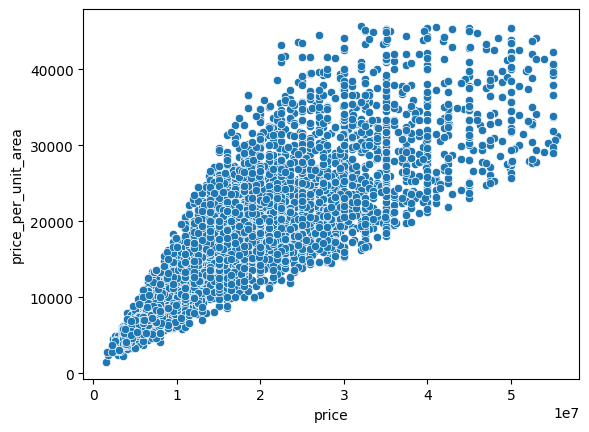

In [375]:
sns.scatterplot(x='price', y='price_per_unit_area', data=data_regression)
plt.show()

In [376]:
data_regression[['price', 'price_per_unit_area']].corr()

,price,price_per_unit_area
price,1.000000,0.815331
price_per_unit_area,0.815331,1.000000


Удалим столбец, так как у него высокая корреляции, а еще это будет утечка данных

In [377]:
data_regression = data_regression.drop(columns=['price_per_unit_area'])
data_regression.head()

,price,area,latitude,longitude,Bedrooms,Bathrooms,Balcony,neworold,parking,Furnished_status,Lift,Status_Ready to Move,Status_Under Construction,type_of_building_Flat,type_of_building_Individual House
0,22400000.0,629.0,19.032800,72.896357,2,2,0,1,0,0,0,False,True,True,False
1,35000000.0,974.0,19.032800,72.896357,3,2,0,1,0,0,0,False,True,True,False
2,31700000.0,968.0,19.085600,72.909277,3,3,0,1,0,0,0,False,True,True,False
3,18700000.0,629.0,19.155756,72.846862,2,2,2,1,2,0,2,True,False,True,False
4,13500000.0,1090.0,19.177555,72.849887,2,2,0,1,0,0,0,True,False,True,False


Наши данные предобработанные, пропущенных значений нету, все столбцы численные, от выбросов избавились. Единственное что нужно сделать, это провести скалирование.

Стандартизация лучше для около нормального распределения, нормализация для других

### Задача классификации

In [378]:
data_classification = pd.read_csv('data/heart.csv')

In [379]:
data_classification.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 293 entries, 0 to 292
Data columns (total 16 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   age                            293 non-null    int64  
 1   sex                            293 non-null    int64  
 2   cp                             293 non-null    int64  
 3   trestbps                       293 non-null    int64  
 4   chol                           293 non-null    int64  
 5   fbs                            293 non-null    int64  
 6   restecg                        293 non-null    int64  
 7   thalach                        293 non-null    int64  
 8   exang                          293 non-null    int64  
 9   oldpeak                        293 non-null    float64
 10  slope                          293 non-null    int64  
 11  ca                             293 non-null    int64  
 12  thal                           293 non-null    int

In [380]:
data_classification.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num,the_ratio_of_trestbps_to_chol,danger_level
0,63,1,1,145,233,1,2,150,0,2.3,3,0,6,0,0.622318,7
1,67,1,4,160,286,0,2,108,1,1.5,2,3,3,2,0.559441,12
2,67,1,4,120,229,0,2,129,1,2.6,2,2,7,1,0.524017,11
3,37,1,3,130,250,0,0,187,0,3.5,3,0,3,0,0.520000,6
4,41,0,2,130,204,0,2,172,0,1.4,1,0,3,0,0.637255,5


Наши данные предобработанные, пропущенных значений нету, все столбцы численные, от выбросов избавились. Единственное что нужно сделать, это провести скалирование и балансировку классов.

Стандартизация лучше для около нормального распределения, нормализация для других

## Разделение выборки на train и test. Dataset and DataLoader

### Задача регрессии

In [381]:
data_regression.head()

,price,area,latitude,longitude,Bedrooms,Bathrooms,Balcony,neworold,parking,Furnished_status,Lift,Status_Ready to Move,Status_Under Construction,type_of_building_Flat,type_of_building_Individual House
0,22400000.0,629.0,19.032800,72.896357,2,2,0,1,0,0,0,False,True,True,False
1,35000000.0,974.0,19.032800,72.896357,3,2,0,1,0,0,0,False,True,True,False
2,31700000.0,968.0,19.085600,72.909277,3,3,0,1,0,0,0,False,True,True,False
3,18700000.0,629.0,19.155756,72.846862,2,2,2,1,2,0,2,True,False,True,False
4,13500000.0,1090.0,19.177555,72.849887,2,2,0,1,0,0,0,True,False,True,False


In [382]:
y = data_regression['price'].astype('float32').values
X = data_regression.drop(columns=['price']).astype('float32')
y = y.reshape(-1, 1)

In [383]:
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X, y, test_size=0.15, random_state=42, shuffle=True)
X_train_reg.shape, X_test_reg.shape, y_train_reg.shape, y_test_reg.shape

((4628, 14), (817, 14), (4628, 1), (817, 1))

Сделаем скалирование данных (Robust скалирование)

In [384]:
columns_for_scaled = ['area', 'latitude', 'longitude']

scaler = RobustScaler()

X_train_reg[columns_for_scaled] = scaler.fit_transform(X_train_reg[columns_for_scaled])
X_test_reg[columns_for_scaled] = scaler.transform(X_test_reg[columns_for_scaled])

Подготовка данных для PyTorch

In [386]:
X_train_reg = X_train_reg.values
X_test_reg = X_test_reg.values

Масштаб loss влияет на градиенты: большой y -> большой loss

* Если loss огромный, то градиенты тоже будут огромные → шаг оптимизатора (optimizer.step()) может “взрывать” веса → обучение нестабильное.

* Если loss слишком маленький, наоборот, градиенты почти нулевые → обучение будет очень медленным.

Сделаем маленький learning_rate для большого y

In [ ]:
# scaler_y = RobustScaler()
# y_train_reg_scaled = scaler_y.fit_transform(y_train_reg.reshape(-1, 1))
# y_test_reg_scaled  = scaler_y.transform(y_test_reg.reshape(-1, 1))

In [387]:
reg_train_ds = TensorDataset(torch.from_numpy(X_train_reg), torch.from_numpy(y_train_reg))
reg_train_dl = DataLoader(reg_train_ds, batch_size=256, shuffle=True)

### Задача классификации

In [388]:
data_classification.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num,the_ratio_of_trestbps_to_chol,danger_level
0,63,1,1,145,233,1,2,150,0,2.3,3,0,6,0,0.622318,7
1,67,1,4,160,286,0,2,108,1,1.5,2,3,3,2,0.559441,12
2,67,1,4,120,229,0,2,129,1,2.6,2,2,7,1,0.524017,11
3,37,1,3,130,250,0,0,187,0,3.5,3,0,3,0,0.520000,6
4,41,0,2,130,204,0,2,172,0,1.4,1,0,3,0,0.637255,5


In [389]:
data_classification.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num,the_ratio_of_trestbps_to_chol,danger_level
count,293.000000,293.000000,293.000000,293.000000,293.000000,293.000000,293.000000,293.000000,293.000000,293.000000,293.000000,293.000000,293.000000,293.000000,293.000000,293.000000
mean,54.255973,0.689420,3.146758,131.368601,243.310580,0.150171,0.972696,149.795222,0.327645,0.958703,1.576792,0.634812,4.675768,0.904437,0.557165,6.808874
std,9.095724,0.463523,0.959255,17.493657,44.830531,0.357850,0.996194,23.068667,0.470158,1.041289,0.601147,0.902669,1.932241,1.198350,0.122003,2.346155
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000,0.320755,2.000000
25%,47.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000,0.468085,5.000000
50%,55.000000,1.000000,3.000000,130.000000,240.000000,0.000000,0.000000,153.000000,0.000000,0.600000,2.000000,0.000000,3.000000,0.000000,0.540000,7.000000
75%,61.000000,1.000000,4.000000,140.000000,273.000000,0.000000,2.000000,167.000000,1.000000,1.600000,2.000000,1.000000,7.000000,2.000000,0.633484,8.000000
max,77.000000,1.000000,4.000000,200.000000,360.000000,1.000000,2.000000,202.000000,1.000000,4.000000,3.000000,3.000000,7.000000,4.000000,1.190476,13.000000


In [390]:
y = data_classification['num'].astype('float32').values
X = data_classification.drop(columns=['num']).astype('float32')
y = y.reshape(-1, 1)

In [391]:
X_train_class, X_test_class, y_train_class, y_test_class = train_test_split(X, y, test_size=0.1, random_state=42, shuffle=True, stratify=y)
X_train_class.shape, X_test_class.shape, y_train_class.shape, y_test_class.shape

((263, 15), (30, 15), (263, 1), (30, 1))

#### Сделаем скалирование данных (Robust скалирование)

In [392]:
columns_for_scaled = ['trestbps', 'chol', 'thalach', 'oldpeak', 'the_ratio_of_trestbps_to_chol', 'age']

scaler = RobustScaler()

X_train_class[columns_for_scaled] = scaler.fit_transform(X_train_class[columns_for_scaled])
X_test_class[columns_for_scaled] = scaler.transform(X_test_class[columns_for_scaled])

Подготовка данных для PyTorch

In [393]:
X_train_class_for_trch = X_train_class.values
X_test_class_for_trch = X_test_class.values

In [394]:
class_train_ds = TensorDataset(torch.from_numpy(X_train_class_for_trch), torch.from_numpy(y_train_class))
class_train_dl = DataLoader(class_train_ds, batch_size=64, shuffle=True)

In [395]:
pd.DataFrame(y_train_class).value_counts()

0  
0.0    144
1.0     49
2.0     31
3.0     29
4.0     10
Name: count, dtype: int64

Далее проведем балансировку двумя способами: 

1) SMOTE сэмплирование
2) WeightedRandomSampler в PyTorch DataLoader

#### SMOTE

In [396]:
smote = SMOTE(random_state=42)
X_train_class_smt, y_train_class_smt = smote.fit_resample(X_train_class, y_train_class)

/Users/macbook/Desktop/NLP/nlp_labs/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


In [397]:
pd.DataFrame(y_train_class_smt).value_counts()

0  
0.0    144
1.0    144
2.0    144
3.0    144
4.0    144
Name: count, dtype: int64

Подготовка данных для PyTorch

In [398]:
X_train_class_for_trch_smt = X_train_class_smt.values
X_test_class_for_trch_smt = X_test_class.values

In [399]:
class_smt_train_ds = TensorDataset(torch.from_numpy(X_train_class_for_trch_smt), torch.from_numpy(y_train_class_smt))
class_smt_train_dl = DataLoader(class_smt_train_ds, batch_size=64, shuffle=True)

#### WeightedRandomSampler в PyTorch DataLoader

In [400]:
y_train_tensor = torch.from_numpy(y_train_class).long()

classes = torch.unique(y_train_tensor)

class_sample_count = torch.tensor([(y_train_tensor == t).sum() for t in classes], dtype=torch.float32)

class_weights = 1. / class_sample_count

samples_weight = class_weights[y_train_tensor].view(-1)

In [402]:
class_weights

tensor([0.0069, 0.0204, 0.0323, 0.0345, 0.1000])

In [403]:
sampler = WeightedRandomSampler(
    weights=samples_weight,
    num_samples=len(samples_weight),
    replacement=True
)

In [404]:
class_wrs_train_ds = TensorDataset(torch.from_numpy(X_train_class_for_trch), torch.from_numpy(y_train_class))
class_wrs_train_dl = DataLoader(class_wrs_train_ds, batch_size=64, sampler=sampler)

## Создание архитектуры нейронных сетей и обучение

### Задача регрессии

In [405]:
len(pd.DataFrame(X_train_reg).columns)

14

In [406]:
class MyRegressionModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(14, 120),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(120, 60),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(60, 20),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(20, 1)
        )

    def forward(self, x):
        return self.model(x)

In [407]:
model_reg = MyRegressionModel()
print(model_reg)

MyRegressionModel(
  (model): Sequential(
    (0): Linear(in_features=14, out_features=120, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=120, out_features=60, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=60, out_features=20, bias=True)
    (7): ReLU()
    (8): Dropout(p=0.2, inplace=False)
    (9): Linear(in_features=20, out_features=1, bias=True)
  )
)


In [408]:
loss = nn.MSELoss()

optimizer = torch.optim.Adam(model_reg.parameters(), lr=0.025)

Эпоха 5, Средний loss: 127745730833354.1094
Эпоха 10, Средний loss: 64953428393121.6875
Эпоха 15, Средний loss: 59716967223511.5781
Эпоха 20, Средний loss: 55397314461696.0000
Эпоха 25, Средний loss: 57034801759070.3125
Эпоха 30, Средний loss: 55893626454016.0000
Эпоха 35, Средний loss: 56825032585000.4219
Эпоха 40, Средний loss: 58692416417576.4219
Эпоха 45, Средний loss: 56544366317783.5781
Эпоха 50, Средний loss: 56947192351258.9453


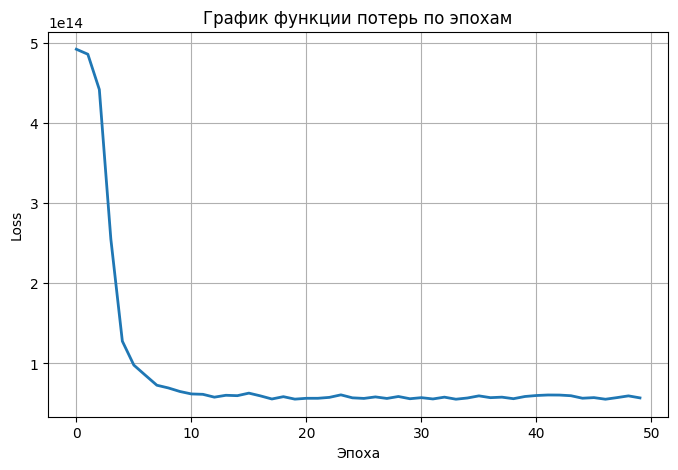

In [409]:
train_model_for_regression(model_reg, loss, optimizer, reg_train_dl)

In [410]:
y_pred_real = predict_values_for_regression(model_reg, X_test_reg)

In [411]:
evaluate_model_for_regression(y_test_reg, y_pred_real)

MAE: 4497437.00
RMSE: 6277597.50
MAPE: 27.88%
R2: 0.6605


#### Подбор гиперпараметров через Optuna

In [467]:
class MyRegressionModel(nn.Module):
    def __init__(self, hidden1, hidden2, hidden3, dropout1, dropout2, dropout3):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(14, hidden1),
            nn.ReLU(),
            nn.Dropout(dropout1),

            nn.Linear(hidden1, hidden2),
            nn.ReLU(),
            nn.Dropout(dropout2),

            nn.Linear(hidden2, hidden3),
            nn.ReLU(),
            nn.Dropout(dropout3),

            nn.Linear(hidden3, 1)
        )

    def forward(self, x):
        return self.model(x)

In [468]:
def train_one_epoch(model, loss, optimizer, train_loader):
    model.train()
    running_loss = 0.0
    for x_b, y_b in train_loader:
        optimizer.zero_grad()
        outputs = model(x_b)
        loss_value = loss(outputs, y_b)
        loss_value.backward()
        optimizer.step()
        running_loss += loss_value.item()
    return running_loss / len(train_loader)

In [ ]:
def objective(trial):
    hidden1 = trial.suggest_int("hidden1", 32, 256)
    hidden2 = trial.suggest_int("hidden2", 16, hidden1)
    hidden3 = trial.suggest_int("hidden3", 8, hidden2)

    dropout1 = trial.suggest_float("dropout1", 0.1, 0.5)
    dropout2 = trial.suggest_float("dropout2", 0.1, 0.5)
    dropout3 = trial.suggest_float("dropout3", 0.1, 0.5)

    lr = trial.suggest_float("lr", 1e-4, 5e-3, log=True)

    model = MyRegressionModel(
        hidden1, hidden2, hidden3,
        dropout1, dropout2, dropout3
    )

    loss_fn = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    for epoch in range(50):
        train_one_epoch(model, loss_fn, optimizer, reg_train_dl)

    model.eval()
    with torch.no_grad():
        val_loss = 0
        for x_b, y_b in reg_train_dl:
            preds = model(x_b)
            val_loss += loss_fn(preds, y_b).item()

    return val_loss / len(reg_train_dl)


In [470]:
study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=50)

print("\nЛучшие параметры:")
print(study.best_params)

[I 2025-11-24 23:56:18,193] A new study created in memory with name: no-name-115fdf06-e212-430f-9b82-bebb09a21652
[I 2025-11-24 23:56:19,614] Trial 0 finished with value: 44961369437669.055 and parameters: {'hidden1': 116, 'hidden2': 72, 'hidden3': 44, 'dropout1': 0.460437322644228, 'dropout2': 0.4103502655315635, 'dropout3': 0.11615957159100816, 'lr': 0.0025880962661544793}. Best is trial 0 with value: 44961369437669.055.
[I 2025-11-24 23:56:20,671] Trial 1 finished with value: 415781035869884.6 and parameters: {'hidden1': 62, 'hidden2': 56, 'hidden3': 22, 'dropout1': 0.3176968786143096, 'dropout2': 0.1366631994445224, 'dropout3': 0.1629507915223508, 'lr': 0.0007076065074766035}. Best is trial 0 with value: 44961369437669.055.
[I 2025-11-24 23:56:22,909] Trial 2 finished with value: 41039994207393.69 and parameters: {'hidden1': 195, 'hidden2': 168, 'hidden3': 97, 'dropout1': 0.25533967316689865, 'dropout2': 0.3852461184433832, 'dropout3': 0.11382837180451247, 'lr': 0.00197118922061551


Лучшие параметры:
{'hidden1': 245, 'hidden2': 234, 'hidden3': 224, 'dropout1': 0.23058987850719942, 'dropout2': 0.2958022566282245, 'dropout3': 0.4542635278727082, 'lr': 0.0027558016791363175}


In [471]:
best = study.best_params

final_model = MyRegressionModel(
    best["hidden1"],
    best["hidden2"],
    best["hidden3"],
    best["dropout1"],
    best["dropout2"],
    best["dropout3"]
)

optimizer = torch.optim.Adam(final_model.parameters(), lr=best["lr"])
loss_fn = nn.MSELoss()

for epoch in range(50):
    loss = train_one_epoch(final_model, loss_fn, optimizer, reg_train_dl)
    print(f"Эпоха {epoch+1}, loss = {loss:.4f}")

Эпоха 1, loss = 495340734561441.6875
Эпоха 2, loss = 501929207329414.7500
Эпоха 3, loss = 484571331883654.7500
Эпоха 4, loss = 478363516486494.3125
Эпоха 5, loss = 464883593855838.3125
Эпоха 6, loss = 390390908439066.9375
Эпоха 7, loss = 290352585810351.1875
Эпоха 8, loss = 178324260202603.7812
Эпоха 9, loss = 124783045571206.7344
Эпоха 10, loss = 103109132853679.1562
Эпоха 11, loss = 91435705123678.3125
Эпоха 12, loss = 82450065543383.5781
Эпоха 13, loss = 73006942850425.2656
Эпоха 14, loss = 67118461009057.6875
Эпоха 15, loss = 61024495799673.2656
Эпоха 16, loss = 57178013509739.7891
Эпоха 17, loss = 55313145818058.1016
Эпоха 18, loss = 52376466234098.5234
Эпоха 19, loss = 51815192088791.5781
Эпоха 20, loss = 50483865252486.7344
Эпоха 21, loss = 48385884325564.6328
Эпоха 22, loss = 46543293796567.5781
Эпоха 23, loss = 44961261268776.4219
Эпоха 24, loss = 46764998856057.2656
Эпоха 25, loss = 47106920284160.0000
Эпоха 26, loss = 45400180281559.5781
Эпоха 27, loss = 43398084510558.3125


In [472]:
y_pred_real = predict_values_for_regression(final_model, X_test_reg)

In [473]:
evaluate_model_for_regression(y_test_reg, y_pred_real)

MAE: 4520459.50
RMSE: 6288739.50
MAPE: 28.40%
R2: 0.6593


### Задача классификации

In [412]:
len(pd.DataFrame(X_train_class_for_trch).columns)

15

#### Несбалансированные данные

In [413]:
class MyClassificationModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(15, 120),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(120, 60),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(60, 20),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(20, 5),
            nn.Softmax(dim=1)
        )

    def forward(self, x):
        return self.model(x)

In [417]:
model_class = MyClassificationModel()
print(model_class)

MyClassificationModel(
  (model): Sequential(
    (0): Linear(in_features=15, out_features=120, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=120, out_features=60, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=60, out_features=20, bias=True)
    (7): ReLU()
    (8): Dropout(p=0.2, inplace=False)
    (9): Linear(in_features=20, out_features=5, bias=True)
    (10): Softmax(dim=1)
  )
)


In [418]:
loss = nn.NLLLoss()

optimizer = torch.optim.Adam(model_reg.parameters(), lr=0.0005)

Эпоха 5, Средний loss: 1.5899
Эпоха 10, Средний loss: 1.5805
Эпоха 15, Средний loss: 1.5814
Эпоха 20, Средний loss: 1.5962
Эпоха 25, Средний loss: 1.5791
Эпоха 30, Средний loss: 1.5737
Эпоха 35, Средний loss: 1.5702
Эпоха 40, Средний loss: 1.5825
Эпоха 45, Средний loss: 1.5876
Эпоха 50, Средний loss: 1.5727


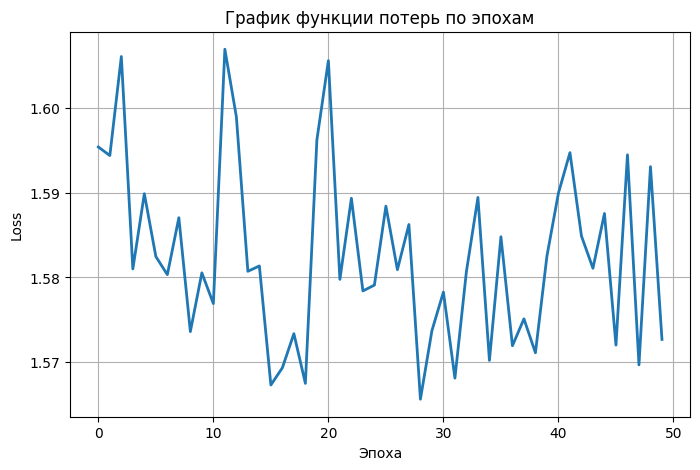

In [419]:
train_model_for_classification(model_class, loss, optimizer, class_train_dl)

In [420]:
y_pred_classes = predict_values_for_classification(model_class, X_test_class_for_trch)

Classification Report:
              precision    recall  f1-score   support

         0.0       0.85      0.69      0.76        16
         1.0       0.00      0.00      0.00         6
         2.0       0.00      0.00      0.00         4
         3.0       0.18      1.00      0.30         3
         4.0       0.00      0.00      0.00         1

    accuracy                           0.47        30
   macro avg       0.20      0.34      0.21        30
weighted avg       0.47      0.47      0.43        30



/Users/macbook/Desktop/NLP/nlp_labs/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/macbook/Desktop/NLP/nlp_labs/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/macbook/Desktop/NLP/nlp_labs/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitaliz

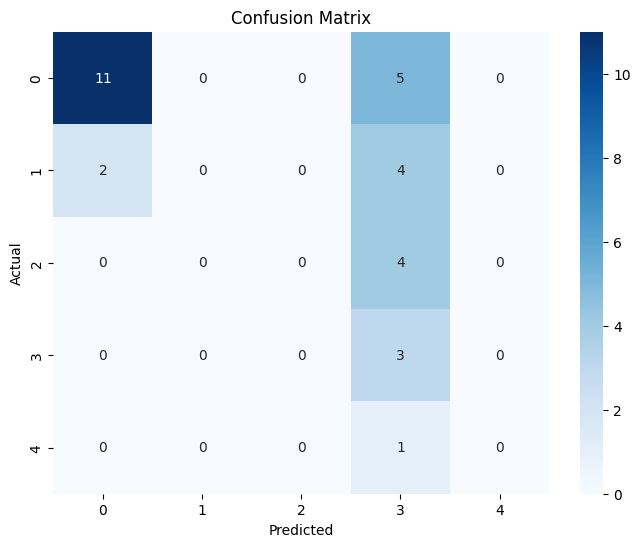

In [421]:
evaluate_model_for_classification(y_test_class, y_pred_classes)

#### SMOTE балансировка

In [422]:
class MyClassificationModelSmote(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(15, 120),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(120, 60),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(60, 20),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(20, 5),
            nn.Softmax(dim=1)
        )

    def forward(self, x):
        return self.model(x)

In [428]:
model_class_smote = MyClassificationModelSmote()

In [429]:
loss = nn.NLLLoss()

optimizer = torch.optim.Adam(model_reg.parameters(), lr=0.0005)

Эпоха 5, Средний loss: 1.6210
Эпоха 10, Средний loss: 1.6163
Эпоха 15, Средний loss: 1.6193
Эпоха 20, Средний loss: 1.6154
Эпоха 25, Средний loss: 1.6153
Эпоха 30, Средний loss: 1.6148
Эпоха 35, Средний loss: 1.6158
Эпоха 40, Средний loss: 1.6141
Эпоха 45, Средний loss: 1.6127
Эпоха 50, Средний loss: 1.6187


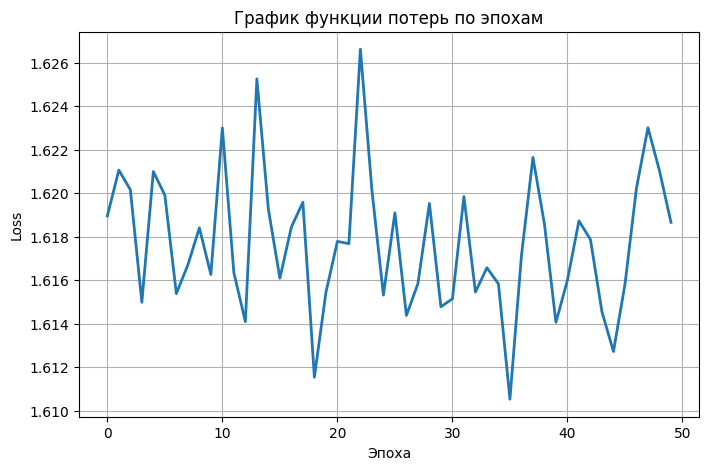

In [430]:
train_model_for_classification(model_class_smote, loss, optimizer, class_smt_train_dl)

In [431]:
y_pred_classes = predict_values_for_classification(model_class_smote, X_test_class_for_trch_smt)

Classification Report:
              precision    recall  f1-score   support

         0.0       0.00      0.00      0.00        16
         1.0       0.20      1.00      0.33         6
         2.0       0.00      0.00      0.00         4
         3.0       0.00      0.00      0.00         3
         4.0       0.00      0.00      0.00         1

    accuracy                           0.20        30
   macro avg       0.04      0.20      0.07        30
weighted avg       0.04      0.20      0.07        30



/Users/macbook/Desktop/NLP/nlp_labs/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/macbook/Desktop/NLP/nlp_labs/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/macbook/Desktop/NLP/nlp_labs/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitaliz

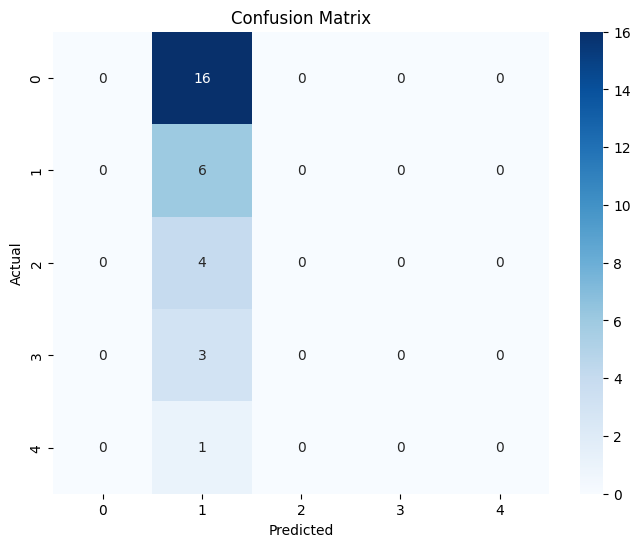

In [432]:
evaluate_model_for_classification(y_test_class, y_pred_classes)

#### WeightedRandomSampler

In [433]:
class MyClassificationModelWRS(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(15, 120),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(120, 60),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(60, 20),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(20, 5),
            nn.Softmax(dim=1)
        )

    def forward(self, x):
        return self.model(x)

In [452]:
model_class_wrs = MyClassificationModelWRS()

In [453]:
loss = nn.NLLLoss()

optimizer = torch.optim.Adam(model_reg.parameters(), lr=0.0005)

Эпоха 5, Средний loss: 1.6020
Эпоха 10, Средний loss: 1.5893
Эпоха 15, Средний loss: 1.6177
Эпоха 20, Средний loss: 1.6016
Эпоха 25, Средний loss: 1.6221
Эпоха 30, Средний loss: 1.6290
Эпоха 35, Средний loss: 1.6281
Эпоха 40, Средний loss: 1.6225
Эпоха 45, Средний loss: 1.6152
Эпоха 50, Средний loss: 1.6275


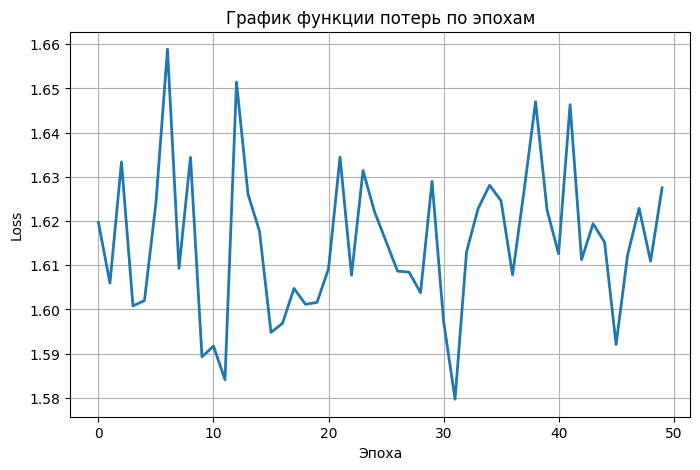

In [454]:
train_model_for_classification(model_class_wrs, loss, optimizer, class_wrs_train_dl)

In [455]:
y_pred_classes = predict_values_for_classification(model_class_wrs, X_test_class_for_trch)

Classification Report:
              precision    recall  f1-score   support

         0.0       1.00      0.06      0.12        16
         1.0       0.00      0.00      0.00         6
         2.0       0.18      0.50      0.27         4
         3.0       0.00      0.00      0.00         3
         4.0       0.06      1.00      0.11         1

    accuracy                           0.13        30
   macro avg       0.25      0.31      0.10        30
weighted avg       0.56      0.13      0.10        30



/Users/macbook/Desktop/NLP/nlp_labs/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/macbook/Desktop/NLP/nlp_labs/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/macbook/Desktop/NLP/nlp_labs/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitaliz

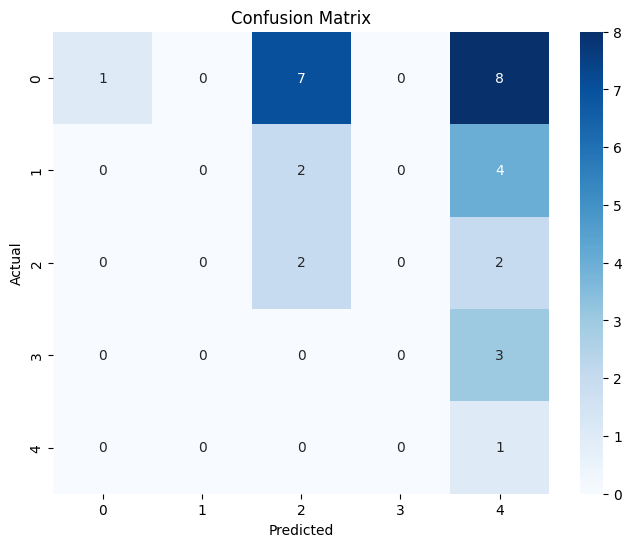

In [456]:
evaluate_model_for_classification(y_test_class, y_pred_classes)